In [1]:
# ==============================================================================
# PIPELINE 6B: Research Question 2 - Predicting Market Failure (Single Bidding)
# Objective: Classify whether a tender will receive 1 or 0 bids based on planning.
# ==============================================================================
import pandas as pd
import numpy as np
from src.training.preparation import perform_group_split
from src.training.optimization import tune_supervised_model
from src.training.evaluation import evaluate_classification, plot_feature_importance

pd.set_option('display.max_columns', None)

In [2]:
# ------------------------------------------------------------------------------
# STEP 1: Load Data & Construct the Binary Target Variable
# ------------------------------------------------------------------------------
print("Loading prepared dataset...")
dataset_prepared = pd.read_parquet("data/prepared/ted_prepared.parquet")

# NUMBER_OF_TENDERS was log1p-transformed in Pipeline 5. 
# We reverse this to accurately identify 0 or 1 bidders.
true_bidder_count = np.expm1(dataset_prepared['NUMBER_OF_TENDERS']).round()

# Create the binary classification target (1 = Single Bidding / Market Failure, 0 = Healthy Competition)
dataset_prepared['TARGET_IS_SINGLE_BIDDING'] = (true_bidder_count <= 1.0).astype(int)

failure_rate = dataset_prepared['TARGET_IS_SINGLE_BIDDING'].mean() * 100
print(f"Dataset Baseline: {failure_rate:.1f}% of all lots suffer from Market Failure.")

Loading prepared dataset...
Dataset Baseline: 62.9% of all lots suffer from Market Failure.


In [3]:
# ------------------------------------------------------------------------------
# STEP 2: Strict Group-Based Split (Preventing Data Leakage)
# ------------------------------------------------------------------------------
# We absolutely MUST drop the original bidder count and any price outcomes.
features_to_exclude = ['TARGET_AWARD_VALUE_EUR', 'LOT_AWARD_VALUE_EUR', 'NUMBER_OF_TENDERS']

features_train, features_test, target_train, target_test, notice_groups_train = perform_group_split(
    df=dataset_prepared, 
    target_col='TARGET_IS_SINGLE_BIDDING', 
    group_col='ID_NOTICE', 
    drop_cols=features_to_exclude
)

Executing Group-based Split (Target: 'TARGET_IS_SINGLE_BIDDING', Grouping by: 'ID_NOTICE')...
 -> Split successful. Train: 1,937,201 rows | Test: 488,326 rows.


In [4]:
# ------------------------------------------------------------------------------
# STEP 3: Automated Hyperparameter Tuning & Model Selection
# ------------------------------------------------------------------------------
# Note: n_iter defines how many random hyperparameter combinations are tested. 
# Increase to 20 or 50 for the final thesis run.

# Model 1: Logistic Regression (Statistical Baseline)
model_logistic = tune_supervised_model(
    features_train, target_train, notice_groups_train, 
    model_name='linear', task='clf', n_iter=5
)

# Model 2: Random Forest (Bagging Ensemble)
model_random_forest = tune_supervised_model(
    features_train, target_train, notice_groups_train, 
    model_name='rf', task='clf', n_iter=5
)

# Model 3: XGBoost (Gradient Boosting Champion)
model_xgboost = tune_supervised_model(
    features_train, target_train, notice_groups_train, 
    model_name='xgboost', task='clf', n_iter=5
)

\nInitiating Hyperparameter Tuning for 'LINEAR' (CLF)...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/home/msuess/Documents/KIDS/Project/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


 -> Best parameters identified: {'model__C': 10.0}
\nInitiating Hyperparameter Tuning for 'RF' (CLF)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
 -> Best parameters identified: {'model__n_estimators': 100, 'model__max_depth': 20}
\nInitiating Hyperparameter Tuning for 'XGBOOST' (CLF)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
 -> Best parameters identified: {'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.01}


=== FINAL EVALUATION: XGBoost Classifier ===
\nEvaluating Classification Model...
 -> Accuracy:  0.7440
 -> Precision: 0.7574
 -> Recall:    0.8723
 -> F1-Score:  0.8108


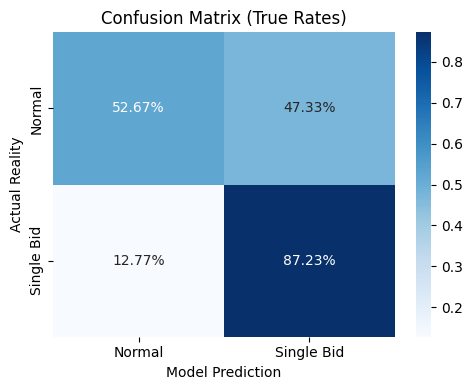

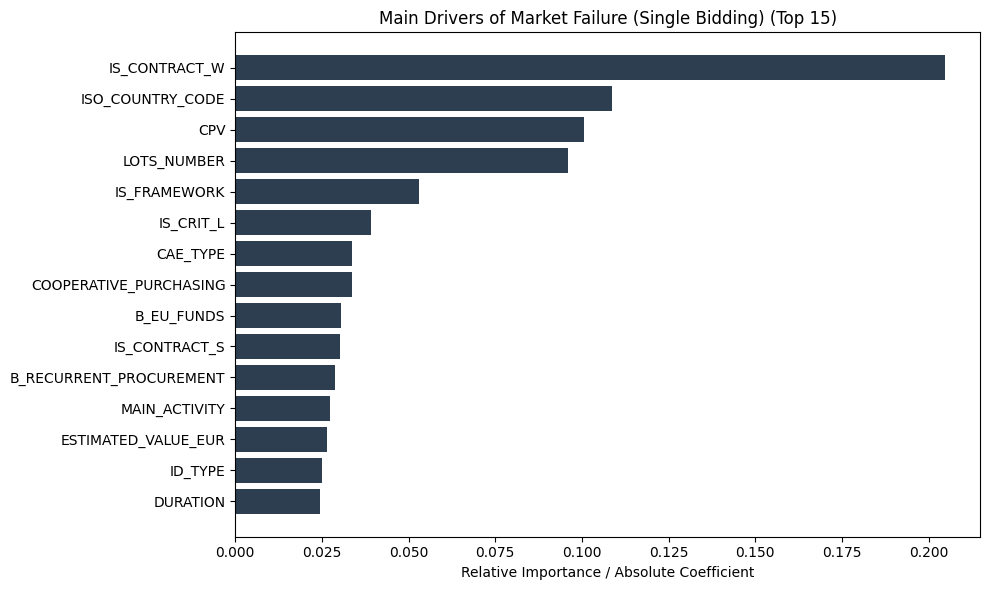

In [6]:
# ------------------------------------------------------------------------------
# STEP 4: Evaluation of the Best Model
# ------------------------------------------------------------------------------
print("=== FINAL EVALUATION: XGBoost Classifier ===")
evaluate_classification(model_xgboost, features_test, target_test)

plot_feature_importance(
    model=model_xgboost, 
    feature_names=features_train.columns, 
    title="Main Drivers of Market Failure (Single Bidding)"
)